In [6]:
import os, random, math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split

In [7]:
#max_in_class = 200
#train_part = 0.5
#noise = 0.1
batch_size = 100

epochs = 10
initial_lr = 0.004

device = "cpu"

In [8]:
dataset_train = torchvision.datasets.MNIST("MNIST_train", train=True, download=True,transform=torchvision.transforms.PILToTensor())
dataset_test = torchvision.datasets.MNIST("MNIST_train", train=False, download=True,transform=torchvision.transforms.PILToTensor())

train_dataloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(dataset_test, batch_size=1, shuffle=True)
print(len(train_dataloader.dataset), len(test_dataloader.dataset))

#for batch in dataloader:
#    print("Batch Data:", batch[0])  
#    print("Batch Labels:", batch[1])

100%|██████████| 9.91M/9.91M [00:06<00:00, 1.52MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 177kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

60000 10000


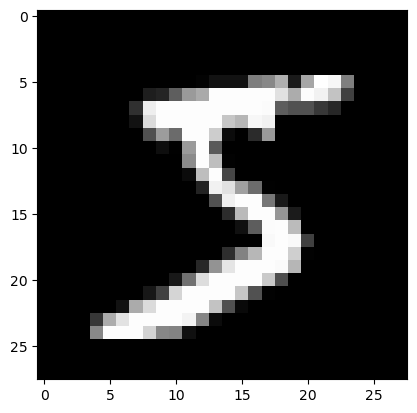

In [9]:
plt.imshow(dataset_train[0][0].reshape(28, 28), cmap='gray')#черно-белое изображение

In [10]:
pd.set_option('display.max_columns', 28)
pd.DataFrame(dataset_train[0][0].reshape(28, 28))#изображение в виде матрицы

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,3,18,18,18,126,136,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,94,154,170,253,253,253,253,253,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,253,253,253,253,253,253,253,251,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,253,253,253,253,198,182,247,241,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,107,253,253,205,11,0,43,154,0,0,0,0,0,0,0,0,0,0


In [11]:
MP1 = nn.MaxPool2d(kernel_size=2, stride= 2)
pd.set_option('display.max_columns', 14)
tmp_MP1 = MP1(dataset_train[0][0])
pd.DataFrame(tmp_MP1.reshape(14, 14))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,18,18,136,175,255,247,0,0
3,0,0,0,49,253,253,253,253,253,225,253,195,0,0
4,0,0,0,18,253,253,253,198,247,0,0,0,0,0
5,0,0,0,0,14,154,253,2,0,0,0,0,0,0
6,0,0,0,0,0,11,253,225,108,0,0,0,0,0
7,0,0,0,0,0,0,81,253,253,150,0,0,0,0
8,0,0,0,0,0,0,0,16,252,253,64,0,0,0
9,0,0,0,0,0,0,148,253,253,253,2,0,0,0


In [12]:
pd.set_option('display.max_columns', 7)
pd.DataFrame(MP1(tmp_MP1).reshape(7, 7))

,0,1,2,3,4,5,6
0,0,0,0,0,0,0,0
1,0,49,253,253,253,255,0
2,0,18,253,253,247,0,0
3,0,0,11,253,253,0,0
4,0,0,0,253,253,64,0
5,0,253,253,253,253,0,0
6,0,253,212,0,0,0,0


In [13]:
MP2 = nn.MaxPool2d(kernel_size=2, stride= 1)
pd.set_option('display.max_columns', 13)
pd.DataFrame(MP2(tmp_MP1).reshape(13, 13))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,18,18,136,175,255,255,247,0
2,0,0,49,253,253,253,253,253,253,255,255,247,0
3,0,0,49,253,253,253,253,253,253,253,253,195,0
4,0,0,18,253,253,253,253,247,247,0,0,0,0
5,0,0,0,14,154,253,253,225,108,0,0,0,0
6,0,0,0,0,11,253,253,253,253,150,0,0,0
7,0,0,0,0,0,81,253,253,253,253,64,0,0
8,0,0,0,0,0,148,253,253,253,253,64,0,0
9,0,0,0,66,253,253,253,253,253,253,2,0,0


In [14]:
tens_1 = torch.Tensor([[1]]*batch_size)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(14*14, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 10)
        #self.drop = nn.Dropout(0.05)

    def forward(self, x):
        x = F.max_pool2d(x, kernel_size =2, stride=2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim = 1)
        return x

In [15]:
model = SimpleNN()
summary(model, (1, 28, 28), batch_size, device = device)
print(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [100, 32]           6,304
            Linear-2                  [100, 32]           1,056
            Linear-3                  [100, 10]             330
Total params: 7,690
Trainable params: 7,690
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.30
Forward/backward pass size (MB): 0.06
Params size (MB): 0.03
Estimated Total Size (MB): 0.38
----------------------------------------------------------------
SimpleNN(
  (fc1): Linear(in_features=196, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=10, bias=True)
)


In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [17]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).float(), y.to(device)

        # Compute prediction error
        #print(X, data_prep(X))
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).float(), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [18]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    #if(t % 2 == 0):
    #    initial_lr /= 2
    #    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    acc, loss = train(train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 34.8%, Avg loss: 2.112649 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 42.7%, Avg loss: 2.034222 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 43.0%, Avg loss: 2.030225 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 41.2%, Avg loss: 2.048809 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 48.8%, Avg loss: 1.972610 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 54.1%, Avg loss: 1.919709 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 56.2%, Avg loss: 1.898772 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 56.0%, Avg loss: 1.900787 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 55.2%, Avg loss: 1.909459 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 50.3%, Avg loss: 1.958448 

Done!


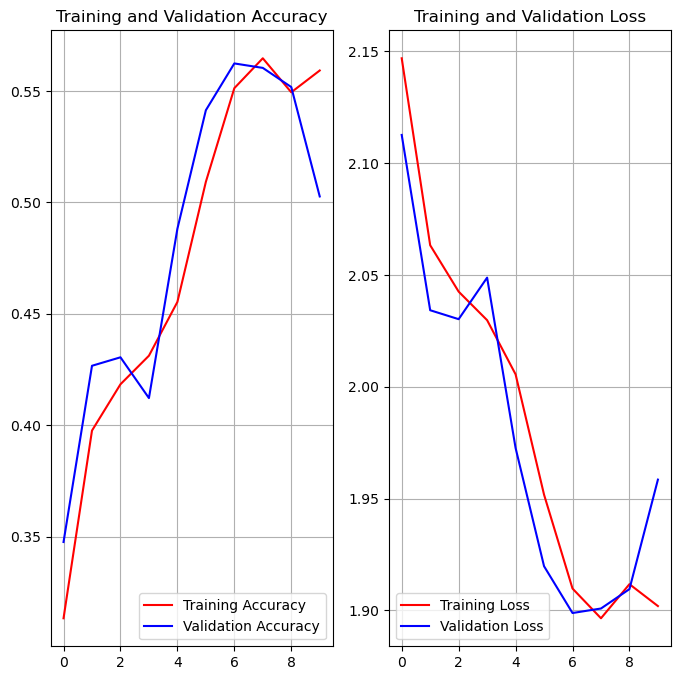

In [19]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

In [38]:
model.eval()
test_dataloader
predictions = torch.LongTensor().to(device)
cmt = torch.zeros(10, 10, dtype=torch.int32)#Матрица ошибок
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model(X.to(device))
        predictions = preds.argmax(dim=1)
        cmt[y, predictions] += 1
    

In [21]:
pd.set_option('display.max_columns', 10)
pd.DataFrame(cmt.reshape(10, 10))#строка истинное значение, столбец предсказанное

,0,1,2,3,4,5,6,7,8,9
0,0,0,93,0,5,787,63,29,3,0
1,0,0,83,0,39,113,62,253,562,23
2,0,0,889,0,20,25,31,32,35,0
3,0,0,122,0,12,743,19,83,28,3
4,0,0,1,0,958,0,9,12,2,0
5,0,0,10,0,21,811,17,31,1,1
6,0,0,48,0,29,45,811,22,3,0
7,0,0,12,0,16,1,1,994,4,0
8,0,0,6,0,61,224,44,95,541,3
9,0,0,1,0,641,25,4,313,2,23
